In [2]:
import pandas as pd

# 1. Caricamento del dataset scaricato da Kaggle
df = pd.read_csv("games.csv")
print(f"Partite totali nel dataset originale: {len(df)}")

# 2. LA MODIFICA: Rimuoviamo i pareggi per un modello binario puro
df = df[df['winner'] != 'draw'].copy()

# 3. Selezione delle colonne che ci interessano e pulizia dei nulli
colonne_utili = ['moves', 'white_rating', 'black_rating', 'winner']
df = df[colonne_utili].copy()
df = df.dropna()

# 4. Creazione Colonna Target e Feature Iniziale
# Ora abbiamo solo 'white' e 'black'. 
# 1 = Vittoria Bianco, 0 = Vittoria Nero
df['Vittoria_Bianco'] = (df['winner'] == 'white').astype(int)

# Calcoliamo il divario di bravura (fondamentale per aiutare il modello)
df['Differenza_Elo'] = df['white_rating'] - df['black_rating']

# 5. Filtro per le partite arrivate almeno alla mossa 20 (40 ply)
# Contiamo gli spazi nella stringa 'moves' per capire quanto è durata
df['numero_mezze_mosse'] = df['moves'].apply(lambda x: len(str(x).split()))
df_filtrato = df[df['numero_mezze_mosse'] >= 40].copy()

# 6. Salviamo solo l'essenziale per il prossimo script
df_finale = df_filtrato[['moves', 'Differenza_Elo', 'Vittoria_Bianco']].copy()

print(f"Partite valide per l'addestramento: {len(df_finale)}")
# Visualizziamo le prime 5 righe
print(df_finale.head())

Partite totali nel dataset originale: 20058
Partite valide per l'addestramento: 13616
                                               moves  Differenza_Elo  \
2  e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...              -4   
3  d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...             -15   
4  e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...              54   
8  e4 e5 Bc4 Nc6 Nf3 Nd4 d3 Nxf3+ Qxf3 Nf6 h3 Bc5...              47   
9  e4 d5 exd5 Qxd5 Nc3 Qe5+ Be2 Na6 d4 Qf5 Bxa6 b...             172   

   Vittoria_Bianco  
2                1  
3                1  
4                1  
8                0  
9                1  


In [3]:
import pandas as pd
import chess

# Dizionario con il numero esatto di pezzi a inizio partita
# Maiuscole = Bianco, Minuscole = Nero
pezzi_standard = {
    'P': 8, 'N': 2, 'B': 2, 'R': 2, 'Q': 1, 'K': 1,
    'p': 8, 'n': 2, 'b': 2, 'r': 2, 'q': 1, 'k': 1
}

def estrai_coordinate(mosse_str):
    """
    Gioca la partita fino alla mossa 20 (40 ply) ed estrae le coordinate X,Y.
    """
    board = chess.Board()
    mosse = str(mosse_str).split()
    
    # Facciamo avanzare la partita di esattamente 40 mezze-mosse
    for mossa in mosse[:40]:
        try:
            board.push_san(mossa)
        except:
            break
            
    # Contatori per tracciare quanti pezzi di ogni tipo troviamo
    trovati = {pezzo: 0 for pezzo in pezzi_standard.keys()}
    coord_dict = {}
    
    # Scansioniamo tutte le 64 case della scacchiera
    for square in chess.SQUARES:
        pezzo = board.piece_at(square)
        if pezzo:
            simbolo = pezzo.symbol()
            trovati[simbolo] += 1
            indice = trovati[simbolo]
            
            # Calcoliamo X (colonna) e Y (riga) da 1 a 8
            # La libreria ci dà metodi comodi per file (0-7) e rank (0-7)
            x = chess.square_file(square) + 1
            y = chess.square_rank(square) + 1
            
            coord_dict[f"{simbolo}_{indice}_X"] = x
            coord_dict[f"{simbolo}_{indice}_Y"] = y
            
    # GESTIONE DEI PEZZI CATTURATI (Trucco di Navid)
    # Se abbiamo trovato meno pezzi del previsto, assegniamo (0,0) ai restanti
    for simbolo, max_count in pezzi_standard.items():
        count_trovati = trovati[simbolo]
        for i in range(count_trovati + 1, max_count + 1):
            coord_dict[f"{simbolo}_{i}_X"] = 0
            coord_dict[f"{simbolo}_{i}_Y"] = 0
            
    return coord_dict

print("Estrazione delle coordinate in corso... (potrebbe volerci qualche decina di secondi)")

# 1. Applichiamo la funzione a tutte le righe del dataframe della Fase 1
lista_dizionari = df_finale['moves'].apply(estrai_coordinate).tolist()

# 2. Convertiamo la lista di dizionari in un nuovo DataFrame Pandas
df_coordinate = pd.DataFrame(lista_dizionari)

# 3. Uniamo le coordinate con la Differenza Elo e il Target
# (Resettiamo l'indice per assicurarci che si uniscano perfettamente riga per riga)
df_finale = df_finale.reset_index(drop=True)
df_ml = pd.concat([df_finale[['Differenza_Elo', 'Vittoria_Bianco']], df_coordinate], axis=1)

print("Dataset per il Machine Learning creato con successo!")
print(f"Dimensioni del dataset: {df_ml.shape[0]} righe e {df_ml.shape[1]} colonne.")
print(df_ml.head())

Estrazione delle coordinate in corso... (potrebbe volerci qualche decina di secondi)
Dataset per il Machine Learning creato con successo!
Dimensioni del dataset: 13616 righe e 72 colonne.
   Differenza_Elo  Vittoria_Bianco  Q_1_X  Q_1_Y  K_1_X  K_1_Y  N_1_X  N_1_Y  \
0              -4                1      4      1      5      1      7      1   
1             -15                1      2      8      7      1      6      3   
2              54                1      4      3      7      1      6      3   
3              47                0      6      3      7      1      3      1   
4             172                1      0      0      5      1      1      6   

   R_1_X  R_1_Y  ...  r_2_X  r_2_Y  q_1_X  q_1_Y  Q_2_X  Q_2_Y  R_3_X  R_3_Y  \
0      8      1  ...      0      0      0      0    NaN    NaN    NaN    NaN   
1      1      1  ...      0      0      0      0    NaN    NaN    NaN    NaN   
2      1      1  ...      0      0      6      6    NaN    NaN    NaN    NaN   
3      1   

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Inizio Fase 3: Preparazione dei dati per il Machine Learning...")
df_ml = df_ml.fillna(0)
# 1. Separazione delle Features (X) e del Target (y)
# X conterrà le 65 colonne (Differenza_Elo + le 64 coordinate)
# y conterrà solo 1 o 0
X = df_ml.drop(columns=['Vittoria_Bianco'])
y = df_ml['Vittoria_Bianco']

# 2. Train/Test Split (80% addestramento, 20% test)
# random_state=42 assicura che il taglio sia riproducibile (se lo rilanciate, dividerà i dati sempre allo stesso modo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Partite per l'addestramento (Train): {len(X_train)}")
print(f"Partite per la validazione (Test): {len(X_test)}")

# 3. Inizializzazione dello StandardScaler
scaler = StandardScaler()

# 4. Standardizzazione
# IL TRUCCO: impariamo le regole (fit) e le applichiamo (transform) SOLO sul Train
X_train_scaled = scaler.fit_transform(X_train)

# Sul Test ci limitiamo ad applicare (transform) le regole imparate dal Train
X_test_scaled = scaler.transform(X_test)

print("\nStandardizzazione completata con successo!")
print("Esempio: La 'Differenza_Elo' e le 'Coordinate' ora hanno media ~0 e deviazione standard 1.")

Inizio Fase 3: Preparazione dei dati per il Machine Learning...
Partite per l'addestramento (Train): 10892
Partite per la validazione (Test): 2724

Standardizzazione completata con successo!
Esempio: La 'Differenza_Elo' e le 'Coordinate' ora hanno media ~0 e deviazione standard 1.


In [8]:
import time
from sklearn.linear_model import LogisticRegression

print("--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---")

# =====================================================================
# MODELLO A: Variate dello Steepest Descent (SAGA)
# Utilizza solo il Gradiente (derivata prima)
# =====================================================================
print("\n1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...")
modello_saga = LogisticRegression(solver='saga', max_iter=2000, random_state=42)

start_time_saga = time.time()
modello_saga.fit(X_train_scaled, y_train)
end_time_saga = time.time()

tempo_saga = end_time_saga - start_time_saga
iterazioni_saga = modello_saga.n_iter_[0]

print(f"✅ SAGA completato in {tempo_saga:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_saga}")


# =====================================================================
# MODELLO B: Metodo Quasi-Newton (L-BFGS)
# Approssima la matrice Hessiana (derivata seconda)
# =====================================================================
print("\n2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...")
modello_lbfgs = LogisticRegression(solver='lbfgs', max_iter=2000, random_state=42)

start_time_lbfgs = time.time()
modello_lbfgs.fit(X_train_scaled, y_train)
end_time_lbfgs = time.time()

tempo_lbfgs = end_time_lbfgs - start_time_lbfgs
iterazioni_lbfgs = modello_lbfgs.n_iter_[0]

print(f"✅ L-BFGS completato in {tempo_lbfgs:.3f} secondi.")
print(f"👣 Iterazioni (passi) necessari: {iterazioni_lbfgs}")

print("\n--- ADDESTRAMENTO COMPLETATO ---")

--- INIZIO FASE 4: ADDESTRAMENTO E CONFRONTO OTTIMIZZATORI ---

1. Addestramento Modello A (Solver: SAGA / Steepest Descent)...
✅ SAGA completato in 8.587 secondi.
👣 Iterazioni (passi) necessari: 637

2. Addestramento Modello B (Solver: L-BFGS / Quasi-Newton)...
✅ L-BFGS completato in 0.119 secondi.
👣 Iterazioni (passi) necessari: 29

--- ADDESTRAMENTO COMPLETATO ---


--- INIZIO FASE 5: VALUTAZIONE DELLE PERFORMANCE ---

Confronto Previsioni: I due modelli hanno dato la stessa risposta nel 99.96% dei casi!
Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.

--- CLASSIFICATION REPORT (Modello L-BFGS) ---
                     precision    recall  f1-score   support

  Vittoria Nero (0)       0.68      0.69      0.69      1337
Vittoria Bianco (1)       0.70      0.69      0.69      1387

           accuracy                           0.69      2724
          macro avg       0.69      0.69      0.69      2724
       weighted avg       0.69      0.69      0.69      2724


Generazione della Matrice di Confusione in corso...


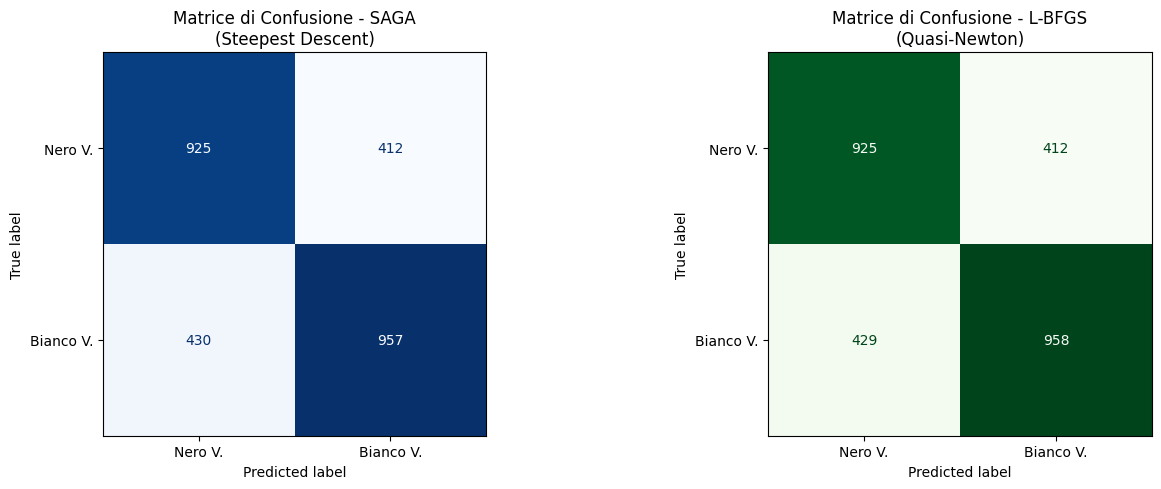

--- VALUTAZIONE COMPLETATA ---


In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- INIZIO FASE 5: VALUTAZIONE DELLE PERFORMANCE ---")

# 1. Generiamo le previsioni sui dati di Test (il 20% che il modello non ha mai visto)
y_pred_saga = modello_saga.predict(X_test_scaled)
y_pred_lbfgs = modello_lbfgs.predict(X_test_scaled)

# 2. Rispondiamo alla domanda di Navid: le previsioni sono diverse?
previsioni_uguali = (y_pred_saga == y_pred_lbfgs).sum()
totale_test = len(y_test)
percentuale_uguaglianza = (previsioni_uguali / totale_test) * 100

print(f"\nConfronto Previsioni: I due modelli hanno dato la stessa risposta nel {percentuale_uguaglianza:.2f}% dei casi!")
print("Questo dimostra che entrambi i solver sono conversi allo stesso minimo globale della funzione convessa.")

# 3. Metriche Classiche (Usiamo i risultati di L-BFGS, visto che sono uguali)
print("\n--- CLASSIFICATION REPORT (Modello L-BFGS) ---")
print(classification_report(y_test, y_pred_lbfgs, target_names=['Vittoria Nero (0)', 'Vittoria Bianco (1)']))

# 4. Matrici di Confusione
print("\nGenerazione della Matrice di Confusione in corso...")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matrice SAGA
cm_saga = confusion_matrix(y_test, y_pred_saga)
disp_saga = ConfusionMatrixDisplay(confusion_matrix=cm_saga, display_labels=['Nero V.', 'Bianco V.'])
disp_saga.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matrice di Confusione - SAGA\n(Steepest Descent)')

# Plot Matrice L-BFGS
cm_lbfgs = confusion_matrix(y_test, y_pred_lbfgs)
disp_lbfgs = ConfusionMatrixDisplay(confusion_matrix=cm_lbfgs, display_labels=['Nero V.', 'Bianco V.'])
disp_lbfgs.plot(ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title('Matrice di Confusione - L-BFGS\n(Quasi-Newton)')

plt.tight_layout()
plt.show()

print("--- VALUTAZIONE COMPLETATA ---")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- INIZIO FASE 6: ANALISI DELLA CONVERGENZA ---")

# 1. Prepariamo i dati da plottare
modelli = ['SAGA\n(Steepest Descent)', 'L-BFGS\n(Quasi-Newton)']
tempi = [tempo_saga, tempo_lbfgs]
iterazioni = [iterazioni_saga, iterazioni_lbfgs]

# 2. Impostazione della figura con due grafici affiancati
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

# --- Grafico 1: Tempo di Addestramento ---
sns.barplot(x=modelli, y=tempi, ax=ax[0], palette=['#3498db', '#2ecc71'])
ax[0].set_title('Tempo di Addestramento (Secondi)', fontsize=16, fontweight='bold')
ax[0].set_ylabel('Secondi', fontsize=12)

# Aggiungiamo le etichette con il valore esatto sopra le barre
for i, v in enumerate(tempi):
    ax[0].text(i, v + (max(tempi)*0.02), f"{v:.3f} s", ha='center', fontsize=12, fontweight='bold')

# --- Grafico 2: Numero di Iterazioni ---
sns.barplot(x=modelli, y=iterazioni, ax=ax[1], palette=['#e74c3c', '#f1c40f'])
ax[1].set_title('Iterazioni per la Convergenza', fontsize=16, fontweight='bold')
ax[1].set_ylabel('Numero di Iterazioni', fontsize=12)

for i, v in enumerate(iterazioni):
    ax[1].text(i, v + (max(iterazioni)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')

# 3. Mostriamo il capolavoro
plt.tight_layout()
plt.show()

print("--- ANALISI DELLA CONVERGENZA COMPLETATA ---")